In [26]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision.transforms import v2
from collections import Counter
from itertools import islice

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Total images in original subset: 5000


C:\Users\bazin\AppData\Local\Temp\ipykernel_25872\710309432.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_counts.values, palette='viridis')


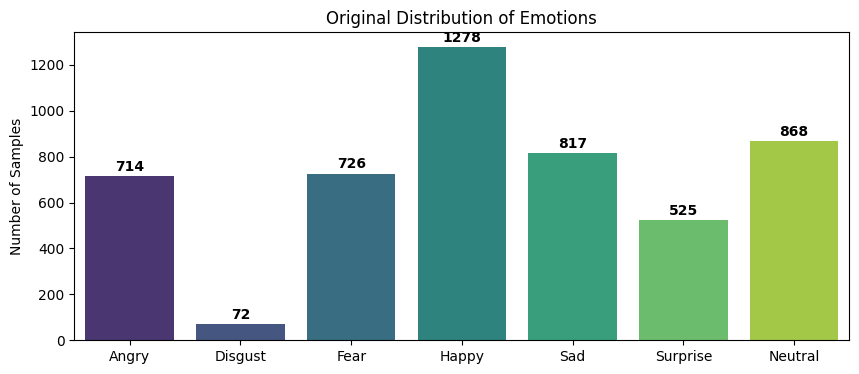

Class 0 (Angry): 714 samples (14.28%)
Class 1 (Disgust): 72 samples (1.44%)
Class 2 (Fear): 726 samples (14.52%)
Class 3 (Happy): 1278 samples (25.56%)
Class 4 (Sad): 817 samples (16.34%)
Class 5 (Surprise): 525 samples (10.50%)
Class 6 (Neutral): 868 samples (17.36%)


In [22]:
# Load the dataset
csv_path = '../data/train_dataset.csv'
df = pd.read_csv(csv_path)

# Standard FER2013 Emotion Mapping
EMOTION_MAP = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Sad',
    5: 'Surprise',
    6: 'Neutral'
}

print(f"Total images in original subset: {len(df)}")

# Class Imbalance
class_counts = df['emotion'].value_counts().sort_index()
class_names = [EMOTION_MAP[i] for i in class_counts.index]

plt.figure(figsize=(10, 4))
sns.barplot(x=class_names, y=class_counts.values, palette='viridis')
plt.title('Original Distribution of Emotions')
plt.ylabel('Number of Samples')
for i, val in enumerate(class_counts.values):
    plt.text(i, val + 10, str(val), ha='center', va='bottom', fontweight='bold')
plt.show()

total_samples = len(df)
for idx, count in class_counts.items():
    print(f"Class {idx} ({EMOTION_MAP[idx]}): {count} samples ({count/total_samples*100:.2f}%)")

In [23]:
class FERDataset(Dataset):
    """
    Custom PyTorch Dataset for loading space-separated pixel values from FER2013 CSV.
    Accommodates on-the-fly transformations and prepares 1-channel grayscale images 
    for 3-channel pre-trained models.
    """
    def __init__(self, dataframe, transform=None):
        pixels = np.stack(dataframe['pixels'].apply(lambda x: np.fromstring(x, sep=' ', dtype=np.float32)).values)
        self.images = pixels.reshape(-1, 1, 48, 48)
        self.images = (self.images - 127.5) / 127.5  # Min-Max Normalization to [-1, 1]
        self.labels = dataframe['emotion'].values
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        if self.transform:
            img = self.transform(img)
            
        img = img.repeat(3, 1, 1) # (1, H, W) -> (3, H, W) for DINO compatibility
        return img, label

In [24]:
train_transforms = v2.Compose([
    v2.Resize((224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),                    
    v2.RandomRotation(degrees=15),                     
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),  
    # v2.RandomErasing(p=0.2, scale=(0.02, 0.1), value=0.0), 
])

val_transforms = v2.Compose([
    v2.Resize((224, 224), antialias=True),
])

In [25]:
# train/validation split
train_size = int(0.8 * len(df))
val_size = len(df) - train_size

train_split, val_split = random_split(df, [train_size, val_size], generator=torch.Generator().manual_seed(RANDOM_SEED))

# Extract clean dataframes from indices
train_df_concrete = df.iloc[train_split.indices].reset_index(drop=True)
val_df_concrete = df.iloc[val_split.indices].reset_index(drop=True)

# class frequencies
train_labels = train_df_concrete['emotion'].values
class_counts_train = Counter(train_labels)

# Inversion
class_weights = {cls: 1.0 / count for cls, count in class_counts_train.items()}

# Mapping class weights
sample_weights = [class_weights[label] for label in train_labels]

# WeightedRandomSampler
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# Instantiate Datasets
train_dataset = FERDataset(train_df_concrete, transform=train_transforms)
val_dataset = FERDataset(val_df_concrete, transform=val_transforms)

# Initialize DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Base Training Split Samples: {len(train_dataset)}")
print(f"Base Validation Split Samples: {len(val_dataset)}")

Base Training Split Samples: 4000
Base Validation Split Samples: 1000


C:\Users\bazin\AppData\Local\Temp\ipykernel_25872\2594295638.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sampler_names, y=sampler_values, palette='magma')


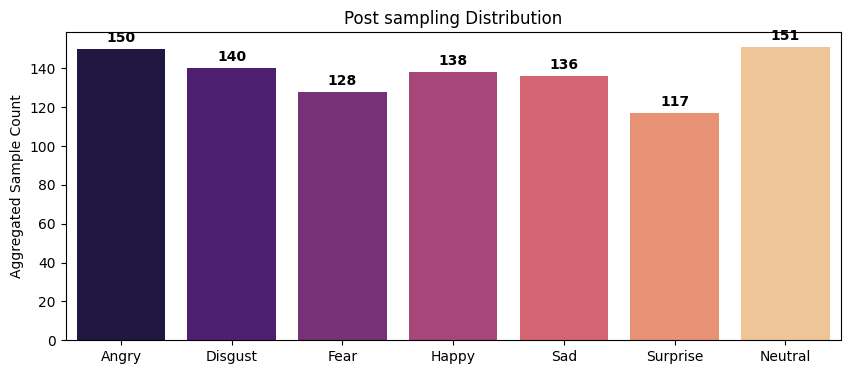

In [27]:
# Track label frequencies
collected_labels = []
for _, labels in islice(train_loader, 30):
    collected_labels.extend(labels.tolist())

sampler_counts = Counter(collected_labels)
sampler_names = [EMOTION_MAP[i] for i in sorted(sampler_counts.keys())]
sampler_values = [sampler_counts[i] for i in sorted(sampler_counts.keys())]

# Plot Sampler Distribution
plt.figure(figsize=(10, 4))
sns.barplot(x=sampler_names, y=sampler_values, palette='magma')
plt.title('Post sampling Distribution')
plt.ylabel('Aggregated Sample Count')
for i, val in enumerate(sampler_values):
    plt.text(i, val + 2, str(val), ha='center', va='bottom', fontweight='bold')
plt.show()


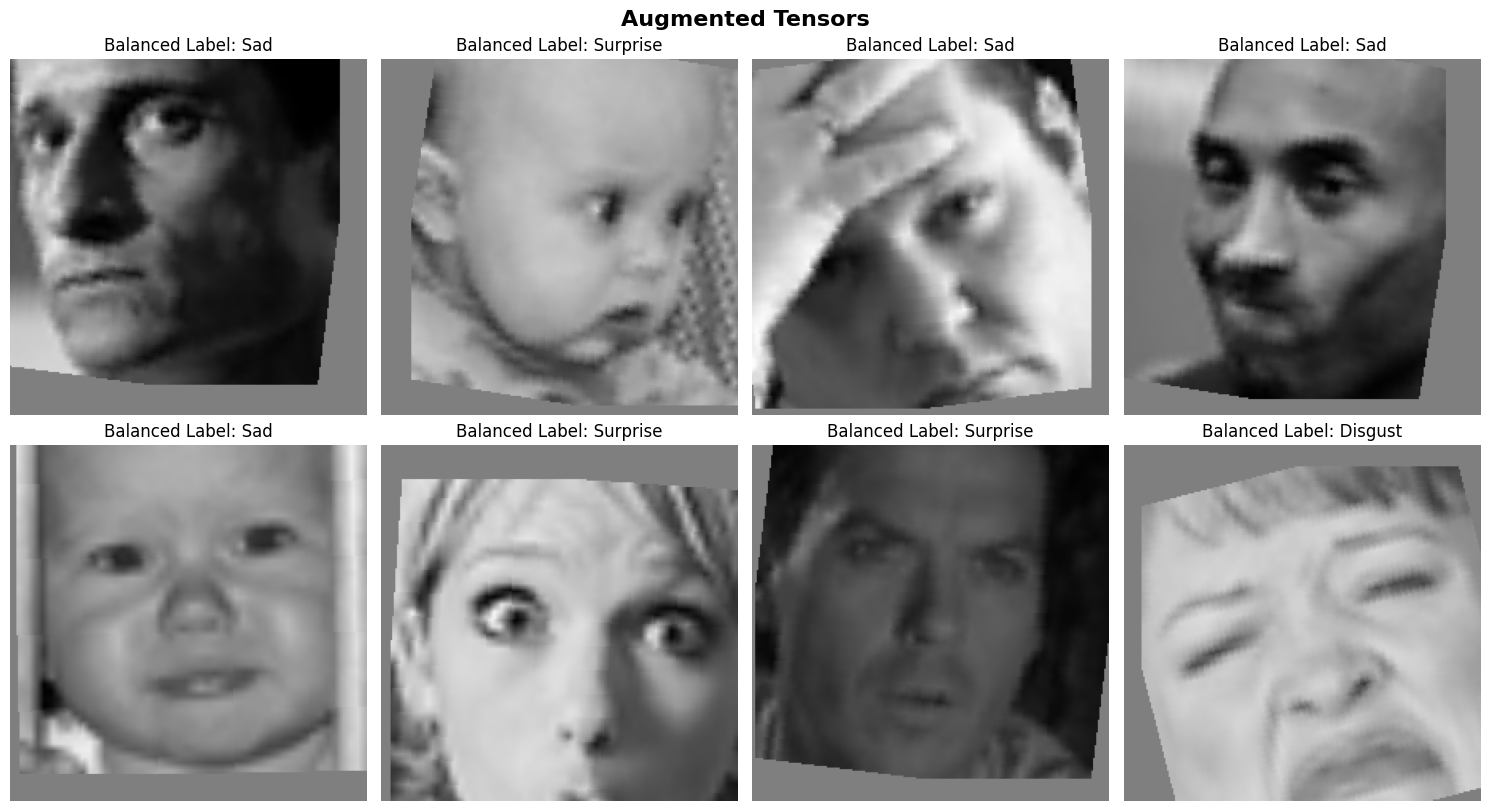

In [28]:
sample_imgs, sample_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i in range(8):
    img = sample_imgs[i]
    label = sample_labels[i].item()
    
    img_to_show = img.permute(1, 2, 0).numpy() * 0.5 + 0.5
    img_to_show = np.clip(img_to_show, 0, 1)
    
    axes[i].imshow(img_to_show)
    axes[i].set_title(f"Balanced Label: {EMOTION_MAP[label]}")
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle("Augmented Tensors", y=1.02, fontsize=16, fontweight='bold')
plt.show()